

> IMPORTS



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import xgboost as xgb
import shap

from collections import Counter
from scipy.stats import randint, uniform, loguniform
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Training Data

train_flag = pd.read_csv('/content/train_flag.csv')

enquiry_data = pd.read_json('/content/enquiry_data_train.json')

accounts_data = pd.read_json('/content/accounts_data_train.json')



In [5]:
#Testing Data
test_flag          = pd.read_csv('/content/test_flag.csv')
enquiry_data_test  = pd.read_json('/content/enquiry_data_test.json')
accounts_data_test = pd.read_json('/content/accounts_data_test.json')

In [6]:
train_flag.shape

(261383, 3)

In [7]:
enquiry_data.shape

(261383, 69)

In [8]:
accounts_data.shape

(223918, 116)

In [9]:
train_flag.head()

,uid,NAME_CONTRACT_TYPE,TARGET
0,XDA69787158,Cash loans,0
1,BSE47789733,Cash loans,0
2,NTJ92213825,Cash loans,0
3,TCQ47571695,Cash loans,0
4,WJZ68772744,Cash loans,0


In [10]:
enquiry_data.head()

,0,1,2,3,4,5,6,7,8,9,...,59,60,61,62,63,64,65,66,67,68
0,"{'enquiry_type': 'Interbank credit', 'enquiry_...","{'enquiry_type': 'Mobile operator loan', 'enqu...","{'enquiry_type': 'Mobile operator loan', 'enqu...","{'enquiry_type': 'Interbank credit', 'enquiry_...","{'enquiry_type': 'Cash loan (non-earmarked)', ...","{'enquiry_type': 'Mortgage', 'enquiry_amt': 44...","{'enquiry_type': 'Revolving loans', 'enquiry_a...","{'enquiry_type': 'Interbank credit', 'enquiry_...",{'enquiry_type': 'Loan for purchase of shares ...,"{'enquiry_type': 'Revolving loans', 'enquiry_a...",...,None,None,None,None,None,None,None,None,None,None
1,"{'enquiry_type': 'Cash loans', 'enquiry_amt': ...","{'enquiry_type': 'Interbank credit', 'enquiry_...","{'enquiry_type': 'Car loan', 'enquiry_amt': 12...","{'enquiry_type': 'Revolving loans', 'enquiry_a...","{'enquiry_type': 'Car loan', 'enquiry_amt': 12...","{'enquiry_type': 'Another type of loan', 'enqu...",{'enquiry_type': 'Loan for the purchase of equ...,"{'enquiry_type': 'Real estate loan', 'enquiry_...","{'enquiry_type': 'Credit card', 'enquiry_amt':...","{'enquiry_type': 'Unknown type of loan', 'enqu...",...,None,None,None,None,None,None,None,None,None,None
2,"{'enquiry_type': 'Revolving loans', 'enquiry_a...","{'enquiry_type': 'Consumer credit', 'enquiry_a...","{'enquiry_type': 'Interbank credit', 'enquiry_...","{'enquiry_type': 'Revolving loans', 'enquiry_a...",{'enquiry_type': 'Loan for purchase of shares ...,"{'enquiry_type': 'Cash loans', 'enquiry_amt': ...","{'enquiry_type': 'Cash loan (non-earmarked)', ...","{'enquiry_type': 'Another type of loan', 'enqu...","{'enquiry_type': 'Consumer credit', 'enquiry_a...","{'enquiry_type': 'Credit card', 'enquiry_amt':...",...,None,None,None,None,None,None,None,None,None,None
3,{'enquiry_type': 'Loan for purchase of shares ...,{'enquiry_type': 'Loan for working capital rep...,"{'enquiry_type': 'Consumer credit', 'enquiry_a...",{'enquiry_type': 'Loan for the purchase of equ...,"{'enquiry_type': 'Another type of loan', 'enqu...",{'enquiry_type': 'Loan for the purchase of equ...,"{'enquiry_type': 'Unknown type of loan', 'enqu...","{'enquiry_type': 'Cash loan (non-earmarked)', ...","{'enquiry_type': 'Cash loans', 'enquiry_amt': ...","{'enquiry_type': 'Consumer credit', 'enquiry_a...",...,None,None,None,None,None,None,None,None,None,None
4,"{'enquiry_type': 'Mobile operator loan', 'enqu...",None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [11]:
accounts_data.head()

,0,1,2,3,4,5,6,7,8,9,...,106,107,108,109,110,111,112,113,114,115
0,"{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...",None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,"{'credit_type': 'Credit card', 'loan_amount': ...",None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,"{'credit_type': 'Consumer credit', 'loan_amoun...",None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,"{'credit_type': 'Credit card', 'loan_amount': ...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Credit card', 'loan_amount': ...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Credit card', 'loan_amount': ...",None,None,...,None,None,None,None,None,None,None,None,None,None
4,"{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Credit card', 'loan_amount': ...",None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [12]:
accounts_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223918 entries, 0 to 223917
Columns: 116 entries, 0 to 115
dtypes: object(116)
memory usage: 198.2+ MB


In [13]:
type(accounts_data.iloc[0,0])

dict

In [14]:
accounts_data.iloc[0,0]

{'credit_type': 'Consumer credit',
 'loan_amount': 272745.0,
 'amount_overdue': 0.0,
 'open_date': '2018-09-22',
 'closed_date': '2020-02-22',
 'payment_hist_string': '000000000000000000000010000000000000000000000000000',
 'uid': 'AAA09044550'}

In [15]:
type(enquiry_data.iloc[0,0])

dict

In [16]:
enquiry_data.iloc[0,0]

{'enquiry_type': 'Interbank credit',
 'enquiry_amt': 168839,
 'enquiry_date': '2020-11-08',
 'uid': 'AAA08065248'}

DATA TRANSFORMATION

In [17]:
def explode_nested(df):
    return pd.DataFrame([
        item
        for row in df.values
        for item in row
        if isinstance(item, dict)
    ])

accounts_long      = explode_nested(accounts_data)
enquiry_long       = explode_nested(enquiry_data)
accounts_long_test = explode_nested(accounts_data_test)
enquiry_long_test  = explode_nested(enquiry_data_test)

In [18]:
accounts_long.shape


(1245310, 7)

In [19]:
accounts_long.columns

Index(['credit_type', 'loan_amount', 'amount_overdue', 'open_date',
       'closed_date', 'payment_hist_string', 'uid'],
      dtype='object')

In [20]:
enquiry_long.shape


(1909926, 4)

In [21]:
enquiry_long.columns

Index(['enquiry_type', 'enquiry_amt', 'enquiry_date', 'uid'], dtype='object')

In [22]:
accounts_long.describe(include='all')

,credit_type,loan_amount,amount_overdue,open_date,closed_date,payment_hist_string,uid
count,1245310,1.245307e+06,1.245310e+06,1245310,782275,1245310,1245310
unique,15,NaN,NaN,2923,2913,45212,223918
top,Consumer credit,NaN,NaN,2020-01-03,2020-04-03,000000000000000000,TNK96292343
freq,908741,NaN,NaN,948,593,103179,116
mean,NaN,3.523541e+05,4.202288e+01,NaN,NaN,NaN,NaN
std,NaN,1.109812e+06,6.668687e+03,NaN,NaN,NaN,NaN
min,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN
25%,NaN,5.114700e+04,0.000000e+00,NaN,NaN,NaN,NaN
50%,NaN,1.246590e+05,0.000000e+00,NaN,NaN,NaN,NaN
75%,NaN,3.087000e+05,0.000000e+00,NaN,NaN,NaN,NaN


In [23]:
enquiry_long.describe(include='all')

,enquiry_type,enquiry_amt,enquiry_date,uid
count,1909926,1.909926e+06,1909926,1909926
unique,17,NaN,1776,261383
top,Cash loans,NaN,2020-12-27,PLY03601601
freq,303108,NaN,5422,69
mean,NaN,1.160423e+05,NaN,NaN
std,NaN,8.207031e+04,NaN,NaN
min,NaN,1.007000e+03,NaN,NaN
25%,NaN,5.600000e+04,NaN,NaN
50%,NaN,1.080000e+05,NaN,NaN
75%,NaN,1.590000e+05,NaN,NaN


In [24]:
accounts_long.dtypes

,0
credit_type,object
loan_amount,float64
amount_overdue,float64
open_date,object
closed_date,object
payment_hist_string,object
uid,object


In [25]:
enquiry_long.dtypes

,0
enquiry_type,object
enquiry_amt,int64
enquiry_date,object
uid,object


I converted all date columns to pandas datetime format so that I could perform date arithmetic and create time-based features. Using errors='coerce' ensures that any invalid date values are safely converted to NaT rather than causing the pipeline to fail.

In [26]:
for df in [accounts_long, accounts_long_test]:
    df['open_date']   = pd.to_datetime(df['open_date'],   errors='coerce')
    df['closed_date'] = pd.to_datetime(df['closed_date'], errors='coerce')

for df in [enquiry_long, enquiry_long_test]:
    df['enquiry_date'] = pd.to_datetime(df['enquiry_date'], errors='coerce')

I needed a reference date to create age and recency features, so I used the latest available dates in the data. I then validated the date ranges and checked borrower coverage to make sure the account and enquiry datasets were reliable.

In [84]:
ACCT_REFERENCE_DATE = accounts_long['open_date'].max()
ENQ_REFERENCE_DATE  = enquiry_long['enquiry_date'].max()

print(f"Reference dates — accounts: {ACCT_REFERENCE_DATE.date()} | enquiries: {ENQ_REFERENCE_DATE.date()}")

print(f"accounts_long open_date range: {accounts_long['open_date'].min().date()} → {accounts_long['open_date'].max().date()}")
print(f"enquiry_long enquiry_date range: {enquiry_long['enquiry_date'].min().date()} → {enquiry_long['enquiry_date'].max().date()}")
train_uids = set(train_flag['uid'])
acct_uids  = set(accounts_long['uid'])
enq_uids   = set(enquiry_long['uid'])
print(f"\nTrain UIDs : {len(train_uids):,}")
print(f"With account data : {len(train_uids & acct_uids):,} ({len(train_uids & acct_uids)/len(train_uids)*100:.1f}%)")
print(f"With enquiry data : {len(train_uids & enq_uids):,} ({len(train_uids & enq_uids)/len(train_uids)*100:.1f}%)")

Reference dates — accounts: 2021-01-01 | enquiries: 2021-01-01
accounts_long open_date range: 2013-01-01 → 2021-01-01
enquiry_long enquiry_date range: 2015-08-30 → 2021-01-01

Train UIDs : 261,383
With account data : 223,918 (85.7%)
With enquiry data : 261,383 (100.0%)


# EDA

I performed a missing value analysis on all datasets by calculating the percentage of null values in each column. This helped me identify data quality issues, understand which variables might require imputation or special handling, and assess whether any features had excessive missingness that could reduce their predictive value.

In [93]:
print("\n── Missingness ──")
miss_flag     = train_flag.isnull().mean().mul(100).round(2)
miss_accounts = accounts_long.isnull().mean().mul(100).round(2)
miss_enquiry  = enquiry_long.isnull().mean().mul(100).round(2)

print("Flag:\n",     miss_flag)
print("Accounts:\n", miss_accounts)
print("Enquiry:\n",  miss_enquiry)


print("\n── Missingness Interpretation ──")
closed_null = miss_accounts.get('closed_date', 0)
print(f"closed_date is {closed_null:.1f}% null → these are OPEN running loans, not missing data.")
print("  Action: create is_open flag (closed_date is NaN = 1) instead of imputing.")
print(f"payment_hist_string null: {miss_accounts.get('payment_hist_string', 0):.1f}%")
print("  Action: null payment history → borrower has no credit history → fill DPD features with 0.")
print(f"enquiry_amt null: {miss_enquiry.get('enquiry_amt', 0):.1f}%")


── Missingness ──
Flag:
 uid                   0.0
NAME_CONTRACT_TYPE    0.0
TARGET                0.0
dtype: float64
Accounts:
 credit_type             0.00
loan_amount             0.00
amount_overdue          0.00
open_date               0.00
closed_date            37.18
payment_hist_string     0.00
uid                     0.00
dtype: float64
Enquiry:
 enquiry_type    0.0
enquiry_amt     0.0
enquiry_date    0.0
uid             0.0
dtype: float64

── Missingness Interpretation ──
closed_date is 37.2% null → these are OPEN running loans, not missing data.
  Action: create is_open flag (closed_date is NaN = 1) instead of imputing.
payment_hist_string null: 0.0%
  Action: null payment history → borrower has no credit history → fill DPD features with 0.
enquiry_amt null: 0.0%


I checked the target variable distribution to understand the proportion of good and bad borrowers in the training data. This helps identify whether the dataset is balanced or imbalanced, which is critical in credit risk modeling because class imbalance can affect model training, evaluation metrics, and threshold selection. Based on the distribution, I can decide whether techniques such as class weighting, stratified cross-validation, or resampling are needed.

In [94]:
dist = train_flag['TARGET'].value_counts(normalize=True).mul(100).round(2)
print("\nTarget distribution (%):\n", dist)


default_rate = train_flag['TARGET'].mean() * 100
n_bad  = (train_flag['TARGET'] == 1).sum()
n_good = (train_flag['TARGET'] == 0).sum()
ratio  = n_good / n_bad

print(f"\n── Class Imbalance Summary ──")
print(f"Default rate     : {default_rate:.2f}%")
print(f"Bad loans (1)    : {n_bad:,}")
print(f"Good loans (0)   : {n_good:,}")
print(f"Imbalance ratio  : {ratio:.1f}:1 (good:bad)")
print(f"\nImplication: Random classifier scores AUC=0.50.")
print(f"class_weight='balanced' and scale_pos_weight={ratio:.1f} needed in tree models.")
print(f"Expect AUC in 0.62–0.72 range for bureau-only features.")


Target distribution (%):
 TARGET
0    91.94
1     8.06
Name: proportion, dtype: float64

── Class Imbalance Summary ──
Default rate     : 8.06%
Bad loans (1)    : 21,057
Good loans (0)   : 240,326
Imbalance ratio  : 11.4:1 (good:bad)

Implication: Random classifier scores AUC=0.50.
class_weight='balanced' and scale_pos_weight=11.4 needed in tree models.
Expect AUC in 0.62–0.72 range for bureau-only features.


Here I visualized the target distribution using a count plot to quickly assess class balance and identify whether the dataset contains significantly more good borrowers than bad borrowers.

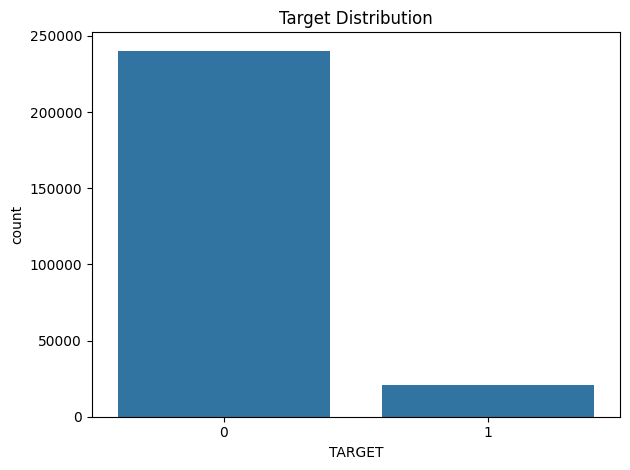

In [30]:
sns.countplot(x='TARGET', data=train_flag)
plt.title("Target Distribution")
plt.tight_layout(); plt.show()

Default rate by NAME_CONTRACT_TYPE

I calculated and visualized the default rate for each contract type to understand whether certain loan products are associated with higher credit risk. This helps identify potentially predictive categorical features and provides business insights into risk across different lending products


Default rate by NAME_CONTRACT_TYPE:
   NAME_CONTRACT_TYPE  default_rate
0         Cash loans      0.083294
1    Revolving loans      0.054548


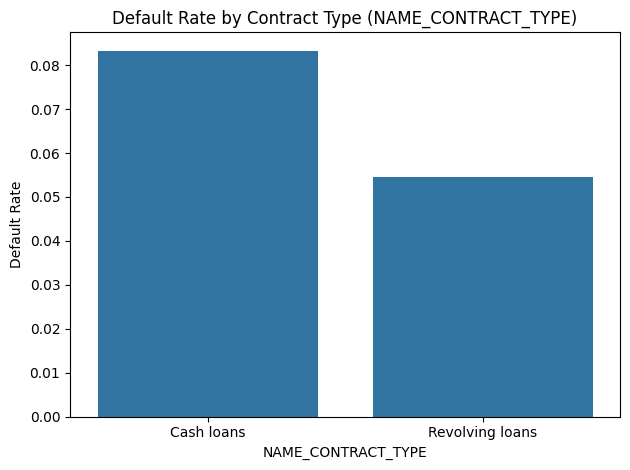

In [31]:
contract_rates = (
    train_flag.groupby('NAME_CONTRACT_TYPE')['TARGET']
    .mean()
    .reset_index()
    .rename(columns={'TARGET': 'default_rate'})
)
print("\nDefault rate by NAME_CONTRACT_TYPE:\n", contract_rates)
sns.barplot(x='NAME_CONTRACT_TYPE', y='default_rate', data=contract_rates)
plt.ylabel("Default Rate")
plt.title("Default Rate by Contract Type (NAME_CONTRACT_TYPE)")
plt.tight_layout(); plt.show()


Top credit / enquiry types

Credit Types Plot:
I analyzed the most common credit types to understand the composition of borrowers' existing credit portfolios and identify dominant loan products in the dataset.

Enquiry Types Plot:
I analyzed the most frequent enquiry types to understand borrowing demand patterns and the kinds of credit products applicants were recently seeking.

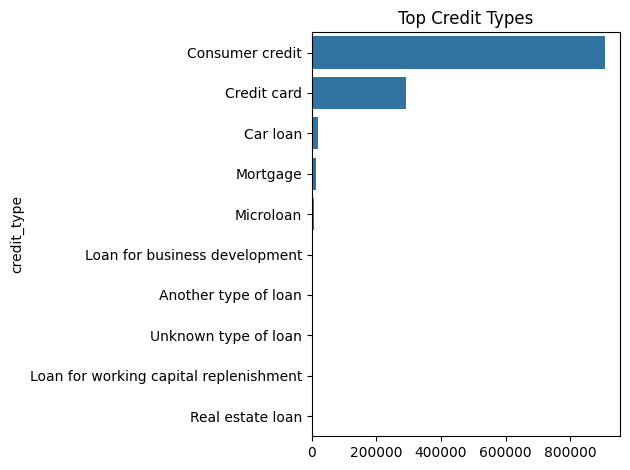

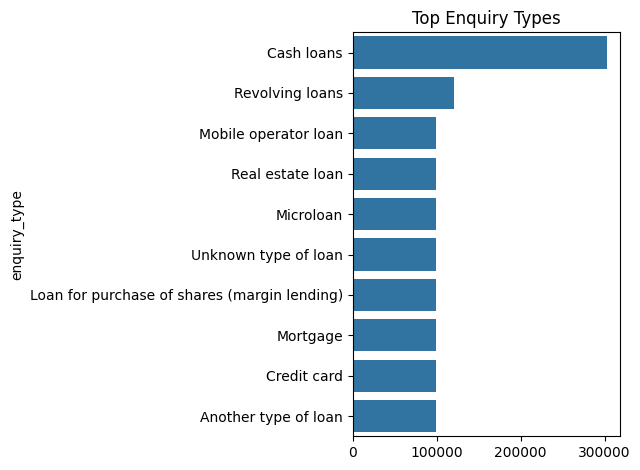

In [32]:
credit_counts = accounts_long['credit_type'].value_counts().head(10)
sns.barplot(x=credit_counts.values, y=credit_counts.index)
plt.title("Top Credit Types"); plt.tight_layout(); plt.show()

top_enq = enquiry_long['enquiry_type'].value_counts().head(10)
sns.barplot(x=top_enq.values, y=top_enq.index)
plt.title("Top Enquiry Types"); plt.tight_layout(); plt.show()

Borrower-level aggregates

I aggregated account and enquiry records to the borrower level (uid) and created summary features to compare borrower characteristics against the target variable.

In [33]:
enq_agg_eda = (
    enquiry_long.groupby('uid')
    .agg(num_enquiries=('enquiry_amt', 'count'),
         total_enquiry_amount=('enquiry_amt', 'sum'))
    .reset_index()
    .merge(train_flag[['uid', 'TARGET']], on='uid', how='left')
)

acct_agg_eda = (
    accounts_long.groupby('uid')
    .agg(num_accounts=('loan_amount', 'count'),
         total_loan_amount=('loan_amount', 'sum'),
         avg_loan_amount=('loan_amount', 'mean'),
         total_overdue=('amount_overdue', 'sum'),
         avg_overdue=('amount_overdue', 'mean'))
    .reset_index()
    .merge(train_flag[['uid', 'TARGET']], on='uid', how='left')
)

Enquiry Level Plots

Enquiries by Default Status

I compared enquiry activity across defaulters and non-defaulters to assess whether recent credit-seeking behavior is associated with higher default risk.

Total Enquiry Amount by Default Status

I analyzed whether borrowers requesting larger credit amounts have different default patterns.

Accounts by Default Status

I compared the number of existing credit accounts between defaulters and non-defaulters to understand the relationship between credit exposure and risk.

Total Overdue by Default Status

I examined overdue balances across target classes since past repayment issues are strong indicators of future default.

Log Loan Amount Distribution

I visualized the distribution of loan amounts after log transformation to reduce skewness and better understand the spread of credit exposure

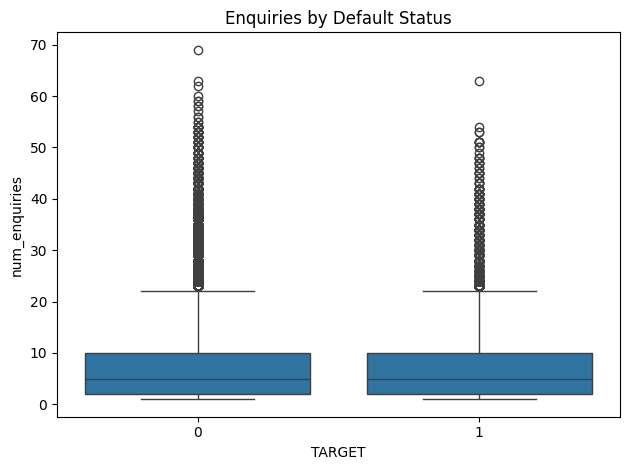

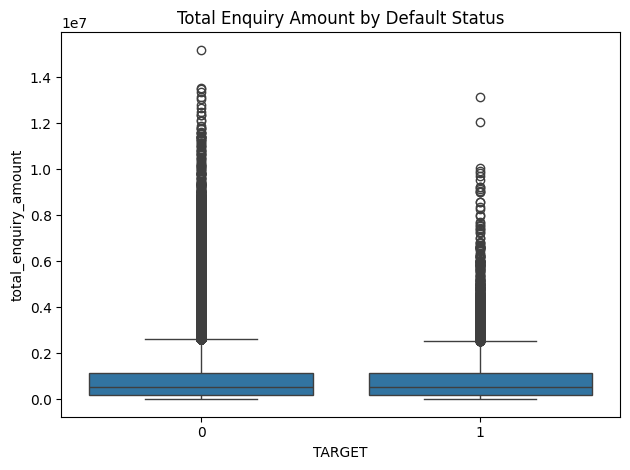

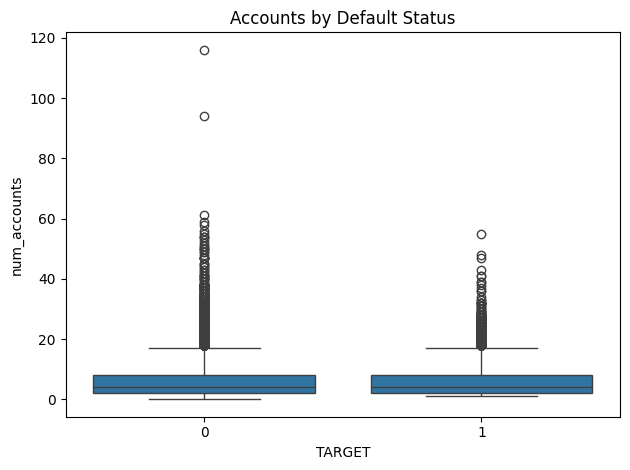

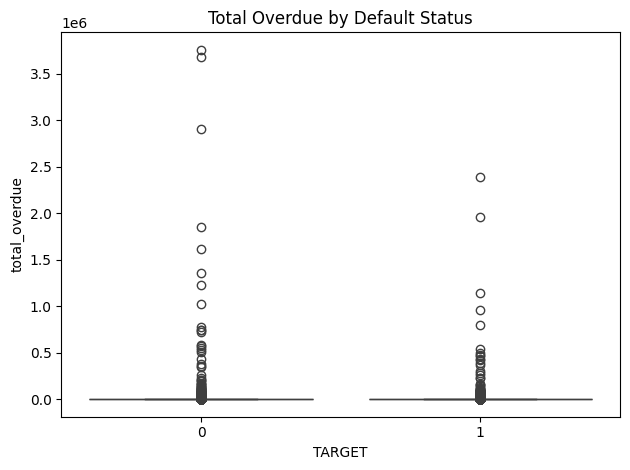

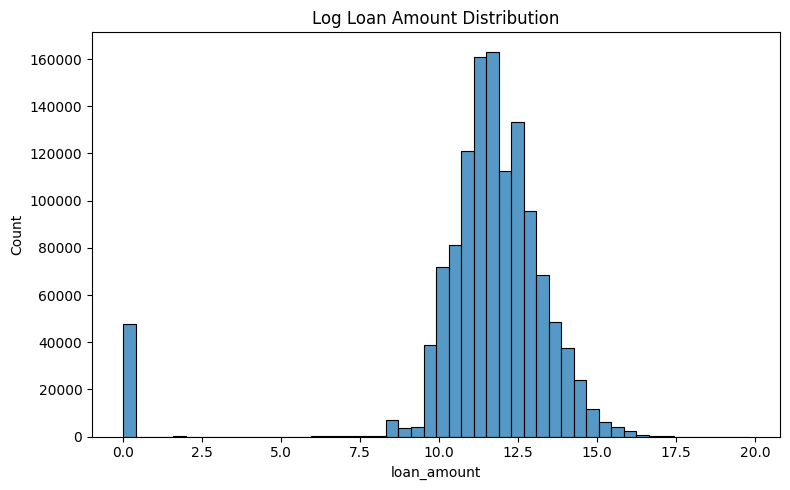

In [34]:
sns.boxplot(x='TARGET', y='num_enquiries',       data=enq_agg_eda)
plt.title("Enquiries by Default Status"); plt.tight_layout(); plt.show()

sns.boxplot(x='TARGET', y='total_enquiry_amount', data=enq_agg_eda)
plt.title("Total Enquiry Amount by Default Status"); plt.tight_layout(); plt.show()

sns.boxplot(x='TARGET', y='num_accounts',   data=acct_agg_eda)
plt.title("Accounts by Default Status"); plt.tight_layout(); plt.show()

sns.boxplot(x='TARGET', y='total_overdue',  data=acct_agg_eda)
plt.title("Total Overdue by Default Status"); plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(accounts_long['loan_amount']), bins=50)
plt.title("Log Loan Amount Distribution"); plt.tight_layout(); plt.show()

Open vs Closed Accounts

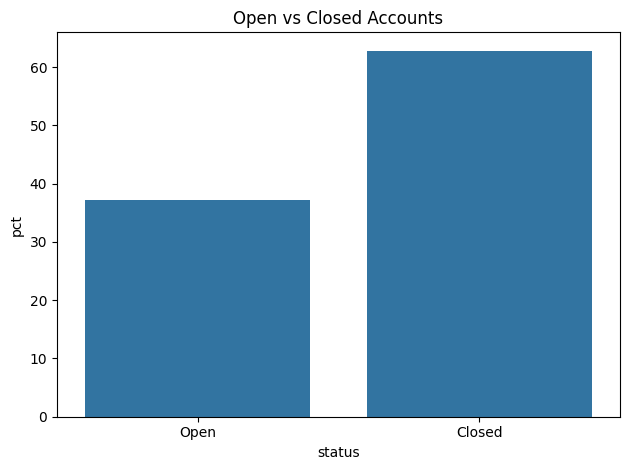

In [35]:
open_pct = accounts_long['closed_date'].isna().mean() * 100
status = pd.DataFrame({'status': ['Open', 'Closed'], 'pct': [open_pct, 100 - open_pct]})
sns.barplot(data=status, x='status', y='pct')
plt.title("Open vs Closed Accounts"); plt.tight_layout(); plt.show()

Default rate by credit/enquiry type

Default Rate by Credit Type

I analyzed default rates across credit types to identify which existing loan products are associated with higher borrower risk.

Default Rate by Enquiry Type

I compared default rates across enquiry types to determine whether demand for specific credit products signals higher default probability.

Default rate by credit_type:
                                      credit_type    TARGET
8             Loan for the purchase of equipment  0.250000
10                                     Microloan  0.205254
9         Loan for working capital replenishment  0.131250
4                                    Credit card  0.088054
3                                Consumer credit  0.075019
0                           Another type of loan  0.072404
14                          Unknown type of loan  0.061497
2                      Cash loan (non-earmarked)  0.058824
6                  Loan for business development  0.058663
1                                       Car loan  0.055838
12                                      Mortgage  0.050546
5                               Interbank credit  0.000000
7   Loan for purchase of shares (margin lending)  0.000000
11                          Mobile operator loan  0.000000
13                              Real estate loan  0.000000


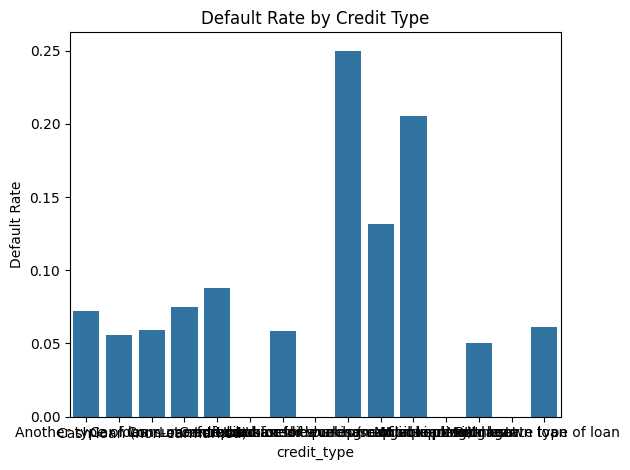


Default rate by enquiry_type:
                                     enquiry_type    TARGET
1                                       Car loan  0.082965
5                                    Credit card  0.082816
14                              Real estate loan  0.082293
8   Loan for purchase of shares (margin lending)  0.082122
0                           Another type of loan  0.081852
3                                     Cash loans  0.081529
10        Loan for working capital replenishment  0.081385
16                          Unknown type of loan  0.081225
11                                     Microloan  0.081219
12                          Mobile operator loan  0.081072
9             Loan for the purchase of equipment  0.080977
6                               Interbank credit  0.080716
13                                      Mortgage  0.080602
2                      Cash loan (non-earmarked)  0.080461
7                  Loan for business development  0.080455
4                       

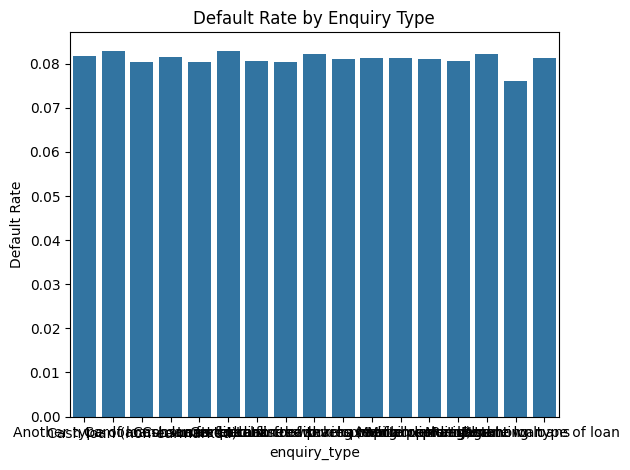

In [36]:
acct_target  = accounts_long.merge(train_flag[['uid', 'TARGET']], on='uid', how='left')
credit_rates = acct_target.groupby('credit_type')['TARGET'].mean().reset_index()
print("Default rate by credit_type:\n", credit_rates.sort_values('TARGET', ascending=False))

sns.barplot(x='credit_type', y='TARGET', data=credit_rates)
plt.ylabel("Default Rate"); plt.title("Default Rate by Credit Type")
plt.tight_layout(); plt.show()

enq_target = enquiry_long.merge(train_flag[['uid', 'TARGET']], on='uid', how='left')
enq_rates  = enq_target.groupby('enquiry_type')['TARGET'].mean().reset_index()
print("\nDefault rate by enquiry_type:\n", enq_rates.sort_values('TARGET', ascending=False))

sns.barplot(x='enquiry_type', y='TARGET', data=enq_rates)
plt.ylabel("Default Rate"); plt.title("Default Rate by Enquiry Type")
plt.tight_layout(); plt.show()

Overdue Distribution

I visualized the distribution of non-zero overdue amounts after log transformation to understand the severity and spread of delinquent balances while reducing the impact of extreme values.

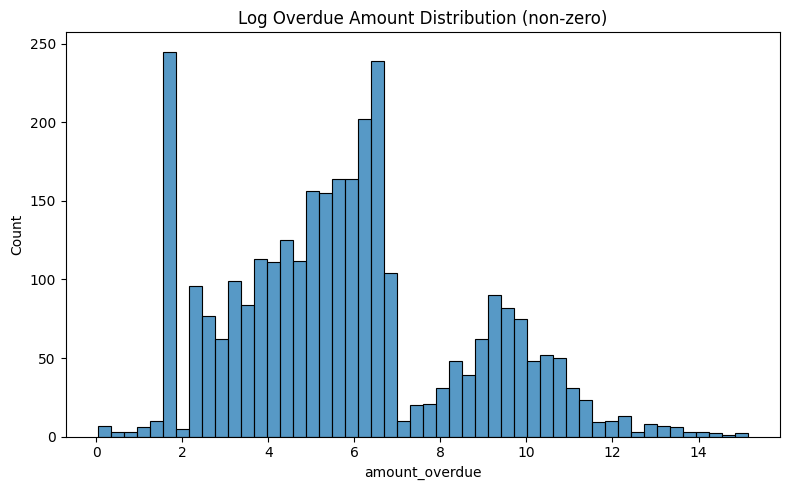

In [37]:
overdue_nonzero = accounts_long.loc[accounts_long['amount_overdue'] > 0, 'amount_overdue']
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(overdue_nonzero), bins=50)
plt.title("Log Overdue Amount Distribution (non-zero)"); plt.tight_layout(); plt.show()

Correlation EDA

Here I analyzed feature correlations to identify relationships between variables, detect potential multicollinearity, and understand which aggregated features show the strongest association with default risk.


Correlation with TARGET:
 TARGET                  1.000000
total_overdue           0.013242
avg_overdue             0.006859
num_accounts            0.005913
num_enquiries           0.001917
total_enquiry_amount   -0.008322
total_loan_amount      -0.013317
avg_loan_amount        -0.019901
Name: TARGET, dtype: float64


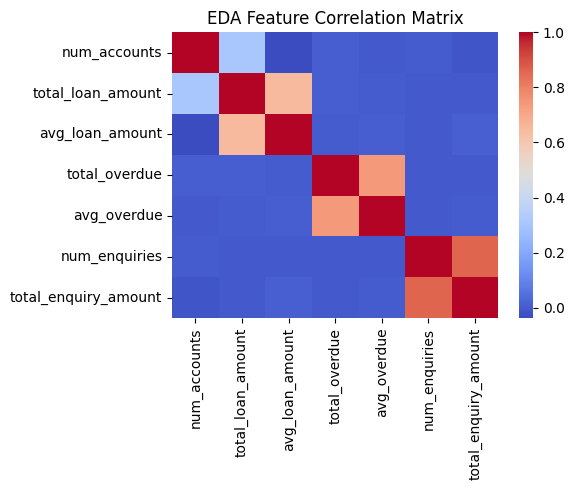

In [38]:
corr_df = (
    acct_agg_eda
    .merge(enq_agg_eda.drop(columns='TARGET'), on='uid', how='inner')
    .fillna(0)
)
corr = corr_df.drop(columns=['uid', 'TARGET']).corr()
print("\nCorrelation with TARGET:\n",
      corr_df.drop(columns='uid').corr()['TARGET'].sort_values(ascending=False))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("EDA Feature Correlation Matrix"); plt.tight_layout(); plt.show()

Log Transformed Views

I applied a log transformation to highly skewed financial variables and compared their distributions across default classes to better understand how credit exposure and overdue balances relate to default risk.

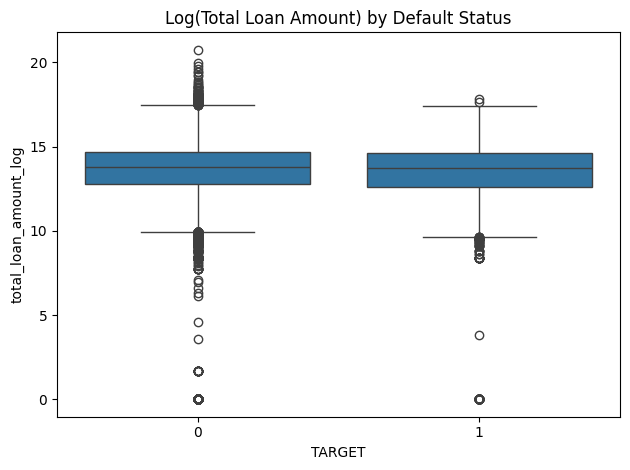

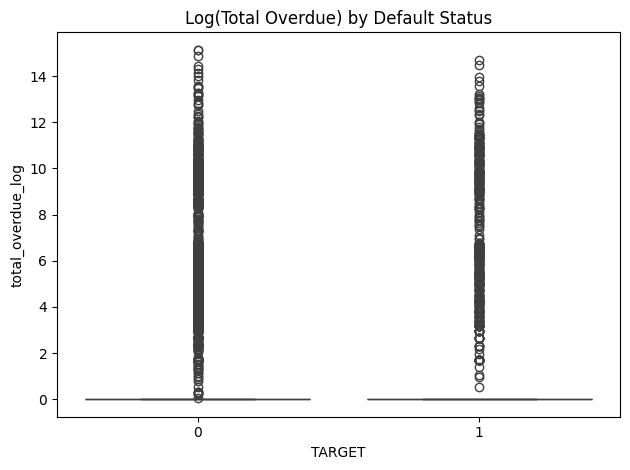

In [39]:
acct_agg_eda['total_loan_amount_log'] = np.log1p(acct_agg_eda['total_loan_amount'])
acct_agg_eda['total_overdue_log']     = np.log1p(acct_agg_eda['total_overdue'])

sns.boxplot(x='TARGET', y='total_loan_amount_log', data=acct_agg_eda)
plt.title("Log(Total Loan Amount) by Default Status"); plt.tight_layout(); plt.show()

sns.boxplot(x='TARGET', y='total_overdue_log', data=acct_agg_eda)
plt.title("Log(Total Overdue) by Default Status"); plt.tight_layout(); plt.show()

DPD trend EDA

I extracted a simple DPD trend feature from the payment history string and compared it across default classes to evaluate whether borrowers with worsening repayment behavior are more likely to default.

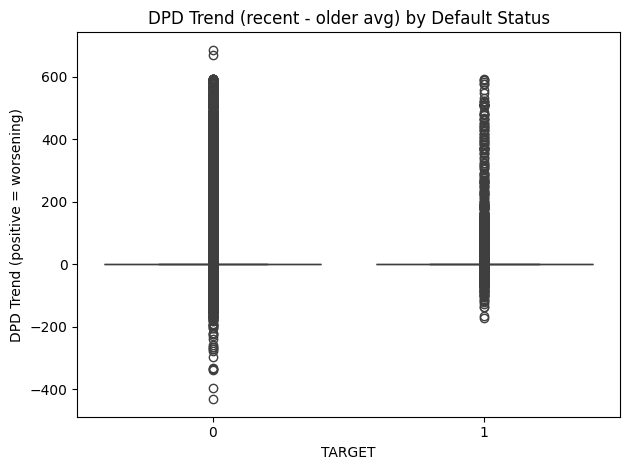

In [40]:
dpd_with_flag = accounts_long.copy()
dpd_with_flag = dpd_with_flag.merge(train_flag[['uid', 'TARGET']], on='uid', how='left')

def _quick_dpd_trend(hist):
    if pd.isna(hist): return np.nan
    s = str(hist)
    if len(s) % 3 != 0: return np.nan
    vals = [int(s[i:i+3]) for i in range(0, len(s), 3)]
    if len(vals) < 6: return np.nan
    half = len(vals) // 2
    return float(np.mean(vals[half:])) - float(np.mean(vals[:half]))

dpd_with_flag['dpd_trend_eda'] = dpd_with_flag['payment_hist_string'].apply(_quick_dpd_trend)
trend_clean = dpd_with_flag[['dpd_trend_eda', 'TARGET']].dropna()
sns.boxplot(x='TARGET', y='dpd_trend_eda', data=trend_clean)
plt.title("DPD Trend (recent - older avg) by Default Status")
plt.ylabel("DPD Trend (positive = worsening)")
plt.tight_layout(); plt.show()

DPD Feature Helper

I parsed the payment history string to create DPD-based features capturing delinquency severity, frequency, recency, and repayment trends, which are strong indicators of default risk.

In [85]:
def compute_dpd_features(hist: object) -> dict:
    empty = dict(
        credit_history_months=0, latest_dpd=0, max_dpd=0, mean_dpd=0.0,
        months_with_dpd=0, recent_3m_max_dpd=0, recent_6m_max_dpd=0,
        recent_12m_max_dpd=0, dpd_trend=0.0,
        dpd_30_plus=0, dpd_60_plus=0, dpd_90_plus=0, dpd_180_plus=0,
        last_6m_dpd_count=0, ever_delinquent=0
    )
    if pd.isna(hist):
        return empty
    s = str(hist)
    if len(s) % 3 != 0:
        return empty
    vals = [int(s[i:i+3]) for i in range(0, len(s), 3)]
    if not vals:
        return empty
    n          = len(vals)
    half       = n // 2
    last_6m    = vals[-6:] if n >= 6 else vals
    recent_12m = vals[-12:]
    return dict(
        credit_history_months = n,
        latest_dpd            = vals[-1],
        max_dpd               = max(vals),
        mean_dpd              = float(np.mean(vals)),
        months_with_dpd       = sum(v > 0 for v in vals),
        recent_3m_max_dpd     = max(vals[-3:]) if n >= 3 else vals[-1],
        recent_6m_max_dpd     = max(last_6m),
        recent_12m_max_dpd    = max(recent_12m),
        dpd_trend             = (np.mean(vals[half:]) - np.mean(vals[:half])) if n >= 2 else 0.0,
        dpd_30_plus           = int(any(v >= 30  for v in vals)),
        dpd_60_plus           = int(any(v >= 60  for v in vals)),
        dpd_90_plus           = int(any(v >= 90  for v in vals)),
        dpd_180_plus          = int(any(v >= 180 for v in vals)),
        last_6m_dpd_count     = sum(v > 0 for v in last_6m),
        ever_delinquent       = int(any(v > 0 for v in vals))
    )

# Feature Engineering

Here I have built a borrower-level feature engineering pipeline that aggregates account, enquiry, credit mix, account age, and DPD repayment history data into a single feature table. The goal was to capture borrower exposure, credit behavior, repayment patterns, enquiry activity, and delinquency risk for model training.

In [88]:
def build_features(account_long, enquiry_long, acct_ref_date, enq_ref_date):
    account_long = account_long.copy()
    enquiry_long = enquiry_long.copy()

    # 1. Account Age
    account_long['account_age_days'] = (acct_ref_date - account_long['open_date']).dt.days
    age_feats = account_long.groupby('uid')['account_age_days'].agg(['max','min','mean']).reset_index()
    age_feats.columns = ['uid','oldest_account_age','newest_account_age','avg_account_age']

    # 2. Basic Aggregates
    account_long['is_open'] = account_long['closed_date'].isna().astype(int)
    acc_feats = account_long.groupby('uid').agg({
        'uid': 'size',
        'is_open': 'sum',
        'loan_amount': ['sum','mean','max'],
        'amount_overdue': ['sum','mean','max']
    })
    acc_feats.columns = [
        'num_accounts','num_open_accounts','total_loan_amount',
        'avg_loan_amount','max_loan_amount','total_overdue','avg_overdue','max_overdue'
    ]
    acc_feats = acc_feats.reset_index()
    acc_feats['num_closed_accounts'] = acc_feats['num_accounts'] - acc_feats['num_open_accounts']
    acc_feats['overdue_ratio'] = acc_feats['total_overdue'] / acc_feats['total_loan_amount'].replace(0, np.nan)
    acc_feats['open_account_ratio'] = acc_feats['num_open_accounts'] / (acc_feats['num_accounts'] + 1)

    # 3. Credit Mix
    mix_dummies = pd.crosstab(account_long['uid'], account_long['credit_type'])                    .rename(columns=lambda c: f'credit_type_{c}').reset_index()
    mix_feats = account_long.groupby('uid')['credit_type'].nunique()                    .reset_index(name='num_credit_types')                    .merge(mix_dummies, on='uid', how='left')

    # 4. Enquiries
    enquiry_long['days_since_enquiry'] = (enq_ref_date - enquiry_long['enquiry_date']).dt.days
    enq_feats = enquiry_long.groupby('uid').agg({
        'uid': 'size',
        'enquiry_amt': ['sum','mean','max'],
        'days_since_enquiry': 'min'
    })
    enq_feats.columns = ['num_enquiries','total_enquiry_amt','avg_enquiry_amt','max_enquiry_amt','days_since_last_enquiry']
    enq_feats = enq_feats.reset_index()

    # 5. DPD
    unique_strings = account_long['payment_hist_string'].unique()
    cache = {s: compute_dpd_features(s) for s in unique_strings}
    dpd_cols_extracted = pd.DataFrame(account_long['payment_hist_string'].map(cache).tolist())
    temp_dpd_df = pd.concat([account_long[['uid']].reset_index(drop=True), dpd_cols_extracted], axis=1)
    dpd_feats = temp_dpd_df.groupby('uid').agg({
        'max_dpd':'max','mean_dpd':'mean','latest_dpd':'max',
        'credit_history_months':'max','months_with_dpd':'sum',
        'recent_3m_max_dpd':'max','recent_6m_max_dpd':'max','recent_12m_max_dpd':'max',
        'dpd_trend':'mean','dpd_30_plus':'sum','dpd_60_plus':'sum',
        'dpd_90_plus':'sum','dpd_180_plus':'sum','last_6m_dpd_count':'sum','ever_delinquent':'sum'
    })
    dpd_feats.columns = [
        'max_dpd_ever','avg_dpd','latest_dpd','credit_history_months','months_with_dpd',
        'recent_3m_max_dpd','recent_6m_max_dpd','recent_12m_max_dpd','dpd_trend',
        'dpd_30_plus','dpd_60_plus','dpd_90_plus','dpd_180_plus','last_6m_dpd_count','ever_delinquent'
    ]
    dpd_feats = dpd_feats.reset_index()

    # 6. Merge all
    features = acc_feats        .merge(age_feats,  on='uid', how='left')        .merge(mix_feats,  on='uid', how='left')        .merge(enq_feats,  on='uid', how='left')        .merge(dpd_feats,  on='uid', how='left')
    #7. Interaction Features
    features['enquiry_to_loan_ratio'] = features['total_enquiry_amt']  / (features['total_loan_amount'] + 1)
    features['overdue_per_account']   = features['total_overdue']       / (features['num_accounts'] + 1)
    features['enquiries_per_account'] = features['num_enquiries']       / (features['num_accounts'] + 1)
    features['dpd_per_account']       = features['months_with_dpd']     / (features['num_accounts'] + 1)

    return features

# Building Training Set

Then I generated borrower-level features, merged them with the target dataset, and handled missing values before modeling. For time-based features such as account age and enquiry recency, I used median imputation, while remaining missing values were filled with zero to create a complete model-ready dataset.

In [43]:
features_train = build_features(
    accounts_long, enquiry_long,
    ACCT_REFERENCE_DATE, ENQ_REFERENCE_DATE
)
print("Feature columns:", len(features_train.columns))


train = train_flag.merge(features_train, on='uid', how='left')


age_cols = [
    'oldest_account_age', 'newest_account_age', 'avg_account_age',
    'credit_history_months', 'days_since_last_enquiry'
]
train_medians = {
    col: train[col].median()
    for col in age_cols
    if col in train.columns
}
for col, med in train_medians.items():
    train[col] = train[col].fillna(med)

train = train.fillna(0)

Feature columns: 51


DPD decile analysis

I grouped borrowers into buckets based on DPD and overdue amounts and checked how default rates changed across those buckets to see if these features were actually capturing risk.

In [45]:

features_train = build_features(accounts_long, enquiry_long, ACCT_REFERENCE_DATE, ENQ_REFERENCE_DATE)

dpd_cols_analysis = ['max_dpd_ever', 'latest_dpd', 'recent_3m_max_dpd', 'months_with_dpd']
dpd_check = features_train.merge(train_flag[['uid', 'TARGET']], on='uid', how='left')

for col in dpd_cols_analysis:
    if col in dpd_check.columns:
        temp = dpd_check[[col, 'TARGET']].copy()

        try:
            temp['bucket'] = pd.qcut(temp[col], q=10, duplicates='drop')
            print(f"\nDefault rate by {col} decile:\n{temp.groupby('bucket', observed=True)['TARGET'].mean()}")
        except ValueError:
            print(f"\nCould not bin {col} - likely too many identical values.")

df_overdue = acct_agg_eda[['uid', 'total_overdue', 'TARGET']].dropna()
df_overdue['bucket'] = pd.qcut(df_overdue['total_overdue'], q=10, duplicates='drop')
print("\nDefault rate by total_overdue decile:")
print(df_overdue.groupby('bucket', observed=True)['TARGET'].mean().reset_index())


Default rate by max_dpd_ever decile:
bucket
(-0.001, 12.0]    0.077520
(12.0, 39.0]      0.080384
(39.0, 101.0]     0.077299
(101.0, 999.0]    0.070412
Name: TARGET, dtype: float64

Default rate by latest_dpd decile:
bucket
(-0.001, 999.0]    0.077068
Name: TARGET, dtype: float64

Default rate by recent_3m_max_dpd decile:
bucket
(-0.001, 9.0]    0.076003
(9.0, 999.0]     0.086789
Name: TARGET, dtype: float64

Default rate by months_with_dpd decile:
bucket
(-0.001, 1.0]    0.077861
(1.0, 2.0]       0.076809
(2.0, 5.0]       0.075337
(5.0, 102.0]     0.071855
Name: TARGET, dtype: float64

Default rate by total_overdue decile:
                bucket    TARGET
0  (-0.001, 3756681.0]  0.077068


# Modelling

I prepared the data for modeling by encoding categorical features and used stratified 5-fold cross-validation so the model could be evaluated fairly across different data splits.

In [46]:
FEATURE_COLS = [c for c in train.columns if c not in ['uid', 'TARGET']]
X = train[FEATURE_COLS].copy()
y = train['TARGET'].values

categorical_features = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=categorical_features)

X.columns = [
    c.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')
    for c in X.columns
]

TRAIN_COLUMNS = X.columns.tolist()

N_FOLDS      = 5
RANDOM_STATE = 42
N_ITER       = 30
CV_INNER     = 3

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

In this phase, I tuned the model's hyperparameters using Randomized Search to find a better-performing configuration without exhaustively testing every possible combination.

In [47]:
print("=" * 70)
print("  PHASE 1 — Hyperparameter Tuning via RandomizedSearchCV")
print("=" * 70)

  PHASE 1 — Hyperparameter Tuning via RandomizedSearchCV


I tuned the Logistic Regression model using Randomized Search and optimized the regularization strength (C) based on ROC-AUC. I used scaling, class balancing, and cross-validation to improve generalization and handle class imbalance.

In [52]:
lr_param_dist = {
    "clf__C": loguniform(1e-3, 10)
}

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_search = RandomizedSearchCV(
    estimator=lr_pipe,
    param_distributions=lr_param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

lr_search.fit(X, y)

print("Best Params:", lr_search.best_params_)
print("Best CV AUC:", lr_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'clf__C': np.float64(0.03148911647956861)}
Best CV AUC: 0.625167229147808


In [59]:
best_lr_params = lr_search.best_params_

I tuned the LightGBM model using Randomized Search to find the best combination of tree complexity, learning rate, sampling, and regularization parameters. The objective was to maximize ROC-AUC while reducing overfitting and improving generalization

In [54]:
lgb_param_dist = {
    "n_estimators":      randint(200, 800),
    "learning_rate":     loguniform(0.01, 0.1),
    "num_leaves":        randint(20, 80),
    "max_depth":         randint(3, 8),
    "min_child_samples": randint(20, 60),
    "subsample":         uniform(0.7, 0.3),
    "colsample_bytree":  uniform(0.7, 0.3),
    "reg_alpha":         loguniform(1e-3, 1),
    "reg_lambda":        loguniform(1e-3, 1),
}

lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(
        class_weight="balanced",
        importance_type="gain",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    param_distributions=lgb_param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    refit=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

lgb_search.fit(X, y)

best_lgb_params = lgb_search.best_params_

print(f"\n✅ Best LGB params : {best_lgb_params}")
print(f"✅ Best LGB CV AUC : {lgb_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best LGB params : {'colsample_bytree': np.float64(0.8001125833417065), 'learning_rate': np.float64(0.01389526449426104), 'max_depth': 5, 'min_child_samples': 41, 'n_estimators': 508, 'num_leaves': 21, 'reg_alpha': np.float64(0.146553541187277), 'reg_lambda': np.float64(0.6541210527692729), 'subsample': np.float64(0.7002336297523043)}
✅ Best LGB CV AUC : 0.6401


I tuned the XGBoost model using Randomized Search across key parameters such as tree depth, learning rate, sampling, and regularization. I also used scale_pos_weight to handle class imbalance and optimized performance based on ROC-AUC.

In [57]:
xgb_param_dist = {
    "n_estimators":     randint(200, 800),
    "learning_rate":    loguniform(0.01, 0.1),
    "max_depth":        randint(3, 7),
    "min_child_weight": randint(1, 6),
    "subsample":        uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma":            loguniform(1e-3, 1),
    "reg_alpha":        loguniform(1e-3, 1),
    "reg_lambda":       loguniform(1e-3, 1),
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=float((y == 0).sum()) / max(float((y == 1).sum()), 1),
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ),
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    refit=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X, y)

best_xgb_params = xgb_search.best_params_

print(f"\n✅ Best XGB params : {best_xgb_params}")
print(f"✅ Best XGB CV AUC : {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best XGB params : {'colsample_bytree': np.float64(0.8821102743060054), 'gamma': np.float64(0.006729728537157748), 'learning_rate': np.float64(0.019782150687183572), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 720, 'reg_alpha': np.float64(0.2073644517790503), 'reg_lambda': np.float64(0.0039459088110999985), 'subsample': np.float64(0.7016566351370807)}
✅ Best XGB CV AUC : 0.6414


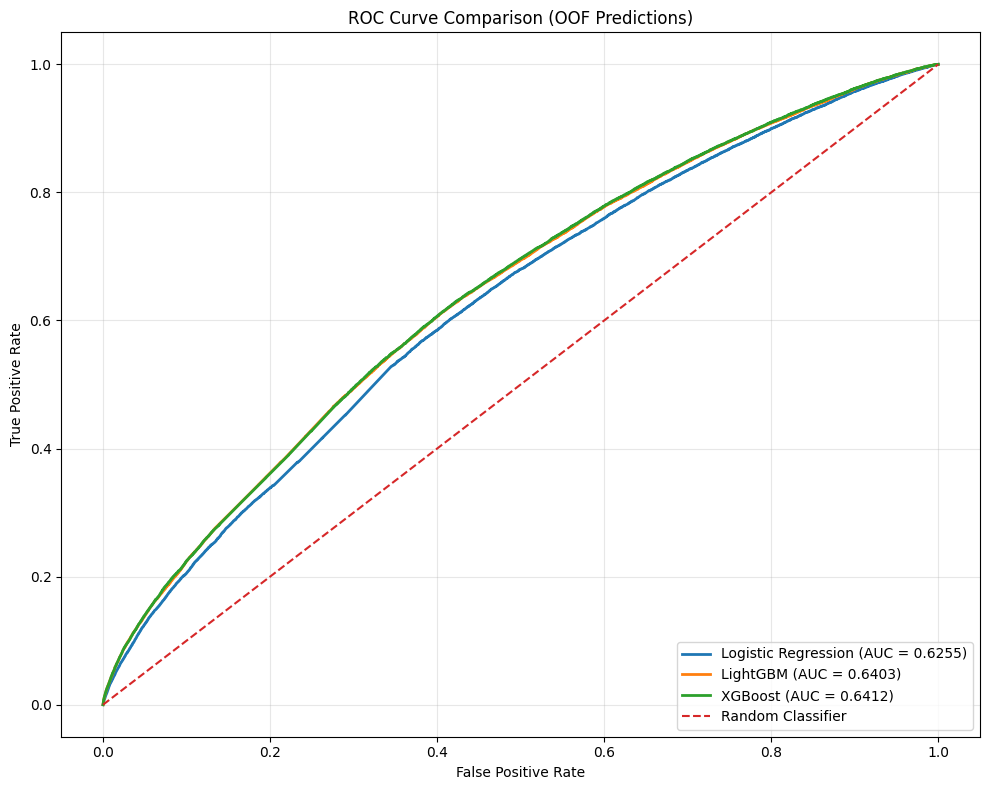

In [102]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y, oof_lr)
plt.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f'Logistic Regression (AUC = {lr_oof_auc:.4f})'
)

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y, oof_lgb)
plt.plot(
    fpr_lgb,
    tpr_lgb,
    linewidth=2,
    label=f'LightGBM (AUC = {lgb_oof_auc:.4f})'
)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y, oof_xgb)
plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f'XGBoost (AUC = {xgb_oof_auc:.4f})'
)

# Random Classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (OOF Predictions)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [99]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "LightGBM", "XGBoost"],
    "ROC_AUC": [
        lr_oof_auc,
        lgb_oof_auc,
        xgb_oof_auc
    ]
})

comparison_df = comparison_df.sort_values("ROC_AUC", ascending=False)
print(comparison_df)

                 Model   ROC_AUC
2              XGBoost  0.641224
1             LightGBM  0.640347
0  Logistic Regression  0.625512


After tuning, I trained the models using 5-fold stratified cross-validation and generated out-of-fold predictions. This provided a reliable estimate of model performance, reduced overfitting, and allowed me to build an ensemble using predictions from Logistic Regression, LightGBM, and XGBoost.

In [75]:
print("=" * 70)
print("  PHASE 2 — 5-Fold Cross-Validation Ensemble Training")
print("=" * 70)

oof_lr  = np.zeros(len(y))
oof_lgb = np.zeros(len(y))
oof_xgb = np.zeros(len(y))

lr_models  = []
lgb_models = []
xgb_models = []

lgb_importance_sum = np.zeros(len(TRAIN_COLUMNS))
xgb_importance_sum = np.zeros(len(TRAIN_COLUMNS))

print("Starting 5-Fold Cross-Validation Ensemble Training...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

    print(f"\nStarting Fold {fold}")

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # ── Logistic Regression ──────────────────────────────────────────────
    lr_kw = {k.replace("clf__", ""): v for k, v in best_lr_params.items()}

    lr_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            **lr_kw,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    lr_model.fit(X_tr, y_tr)

    lr_models.append(lr_model)

    oof_lr[val_idx] = lr_model.predict_proba(X_val)[:, 1]

    # ── LightGBM ─────────────────────────────────────────────────────────
    lgb_model = lgb.LGBMClassifier(
        **best_lgb_params,
        class_weight="balanced",
        importance_type="gain",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    lgb_model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    lgb_models.append(lgb_model)

    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]

    lgb_importance_sum += lgb_model.feature_importances_

    # ── XGBoost ──────────────────────────────────────────────────────────
    fold_scale = float((y_tr == 0).sum()) / max(float((y_tr == 1).sum()), 1)

    xgb_model = xgb.XGBClassifier(
        **best_xgb_params,
        scale_pos_weight=fold_scale,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

    xgb_model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    xgb_models.append(xgb_model)

    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)[:, 1]

    xgb_importance_sum += xgb_model.feature_importances_

    # ── Fold Metrics ─────────────────────────────────────────────────────
    lr_auc = roc_auc_score(y_val, oof_lr[val_idx])
    lgb_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    xgb_auc = roc_auc_score(y_val, oof_xgb[val_idx])

    print(
        f"Fold {fold} | "
        f"LR: {lr_auc:.4f} | "
        f"LGB: {lgb_auc:.4f} | "
        f"XGB: {xgb_auc:.4f}"
    )

# ── Sanity Checks ─────────────────────────────────────────────────────────
print("\nModels trained:")
print("LR :", len(lr_models))
print("LGB:", len(lgb_models))
print("XGB:", len(xgb_models))

print("\nNon-zero OOF predictions:")
print("LR :", np.sum(oof_lr != 0))
print("LGB:", np.sum(oof_lgb != 0))
print("XGB:", np.sum(oof_xgb != 0))

# ── Overall OOF Scores ────────────────────────────────────────────────────
lr_oof_auc = roc_auc_score(y, oof_lr)
lgb_oof_auc = roc_auc_score(y, oof_lgb)
xgb_oof_auc = roc_auc_score(y, oof_xgb)

print(f"\nOverall OOF LR  AUC : {lr_oof_auc:.4f}")
print(f"Overall OOF LGB AUC : {lgb_oof_auc:.4f}")
print(f"Overall OOF XGB AUC : {xgb_oof_auc:.4f}")

# ── Simple Ensemble ───────────────────────────────────────────────────────
oof_ensemble = (oof_lr + oof_lgb + oof_xgb) / 3

print(
    f"\nOverall OOF Simple Ensemble AUC : "
    f"{roc_auc_score(y, oof_ensemble):.4f}"
)

  PHASE 2 — 5-Fold Cross-Validation Ensemble Training
Starting 5-Fold Cross-Validation Ensemble Training...


Starting Fold 1
[LightGBM] [Info] Number of positive: 16846, number of negative: 192260
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.154314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6981
[LightGBM] [Info] Number of data points in the train set: 209106, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

XGBoost achieved the highest Out-of-Fold ROC-AUC of 0.6412 and was selected as the final model. Ensemble methods were evaluated but did not improve performance, indicating that the tree-based models were learning similar patterns. Therefore, final predictions were generated by averaging probabilities from the five cross-validation XGBoost models.

I looked at which features were consistently important across all three models to understand the key drivers of default risk.


Top 30 Features
                           feature  avg_importance
                   avg_account_age        0.849818
                 num_open_accounts        0.594706
                   avg_loan_amount        0.416249
                newest_account_age        0.326950
               num_closed_accounts        0.317129
                open_account_ratio        0.305755
                     total_overdue        0.296397
     NAME_CONTRACT_TYPE_Cash_loans        0.278320
           days_since_last_enquiry        0.273455
             credit_type_Microloan        0.256582
NAME_CONTRACT_TYPE_Revolving_loans        0.248376
                       max_overdue        0.231581
                oldest_account_age        0.186700
                  num_credit_types        0.183041
                 total_loan_amount        0.179048
                   max_loan_amount        0.161138
                   avg_enquiry_amt        0.158628
                      max_dpd_ever        0.142901
           cre

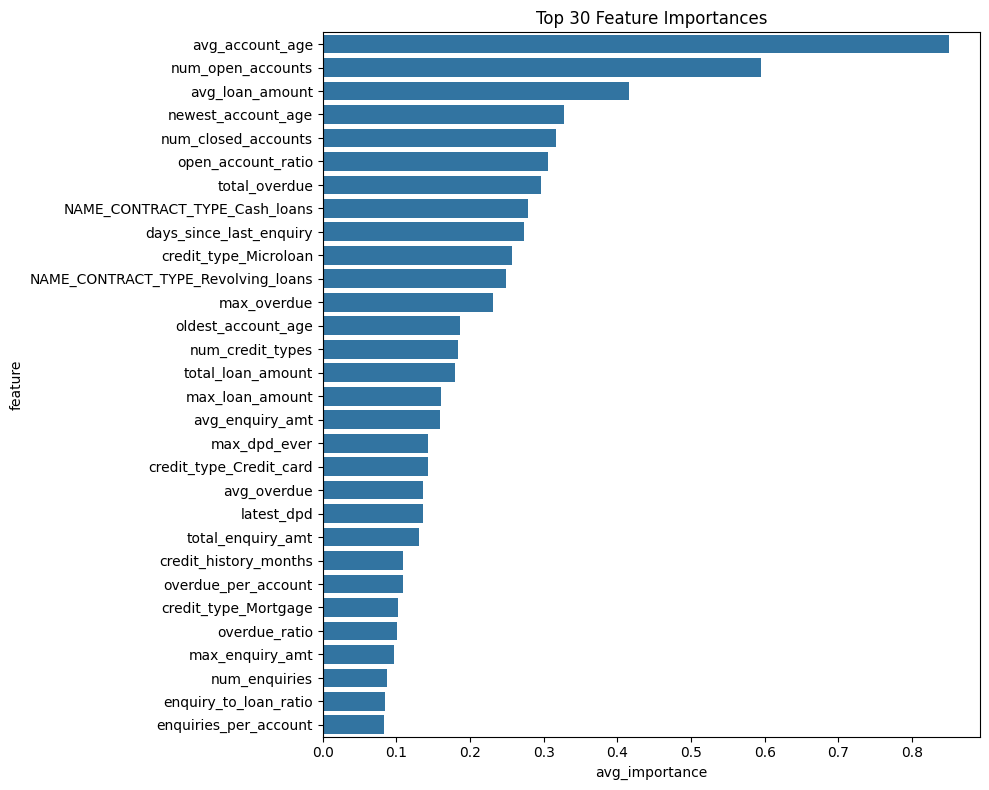

In [78]:
# ── Feature Importance ───────────────────────────────────────────────────────


lr_coef_sum = np.zeros(len(TRAIN_COLUMNS))

for m in lr_models:
    coef = m.named_steps["clf"].coef_
    lr_coef_sum += np.abs(coef[0]) if coef.ndim == 2 else np.abs(coef)

lr_imp_avg = lr_coef_sum / N_FOLDS

importance = pd.DataFrame({
    "feature": TRAIN_COLUMNS,
    "lr_importance": lr_imp_avg,
    "lgb_importance": lgb_importance_sum / N_FOLDS,
    "xgb_importance": xgb_importance_sum / N_FOLDS,
})

for col in ["lr_importance", "lgb_importance", "xgb_importance"]:
    rng = importance[col].max() - importance[col].min()
    importance[col + "_norm"] = (
        importance[col] - importance[col].min()
    ) / (rng + 1e-9)

importance["avg_importance"] = (
    importance["lr_importance_norm"] +
    importance["lgb_importance_norm"] +
    importance["xgb_importance_norm"]
) / 3

importance = (
    importance
    .sort_values("avg_importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 30 Features")
print(
    importance[
        ["feature", "avg_importance"]
    ].head(30).to_string(index=False)
)

plt.figure(figsize=(10, 8))
sns.barplot(
    x="avg_importance",
    y="feature",
    data=importance.head(30)
)
plt.title("Top 30 Feature Importances")
plt.tight_layout()
plt.show()

# Feature Selection

I removed the least important features based on the combined importance scores and retained the most predictive ones. This helped reduce noise and simplify the model without losing much predictive power.

In [79]:
IMPORTANCE_THRESHOLD = importance["avg_importance"].quantile(0.20)

selected_features = importance.loc[
    importance["avg_importance"] > IMPORTANCE_THRESHOLD,
    "feature"
].tolist()

print("\nFeature Selection Summary")
print(f"Before : {len(TRAIN_COLUMNS)}")
print(f"After  : {len(selected_features)}")
print(f"Threshold : {IMPORTANCE_THRESHOLD:.4f}")

dropped = importance[
    importance["avg_importance"] <= IMPORTANCE_THRESHOLD
]

print("\nDropped Features:")
print(dropped["feature"].tolist())


Feature Selection Summary
Before : 56
After  : 44
Threshold : 0.0450

Dropped Features:
['dpd_180_plus', 'credit_type_Loan_for_the_purchase_of_equipment', 'dpd_60_plus', 'ever_delinquent', 'credit_type_Loan_for_working_capital_replenishment', 'dpd_90_plus', 'credit_type_Another_type_of_loan', 'credit_type_Loan_for_purchase_of_shares_margin_lending', 'credit_type_Unknown_type_of_loan', 'credit_type_Cash_loan_non_earmarked', 'credit_type_Interbank_credit', 'credit_type_Mobile_operator_loan']


# Shap Analysis

I used SHAP to interpret the XGboost model and understand how each feature influenced predictions. This helped validate that the model was learning meaningful credit risk patterns and improved explainability.


Running SHAP Analysis...


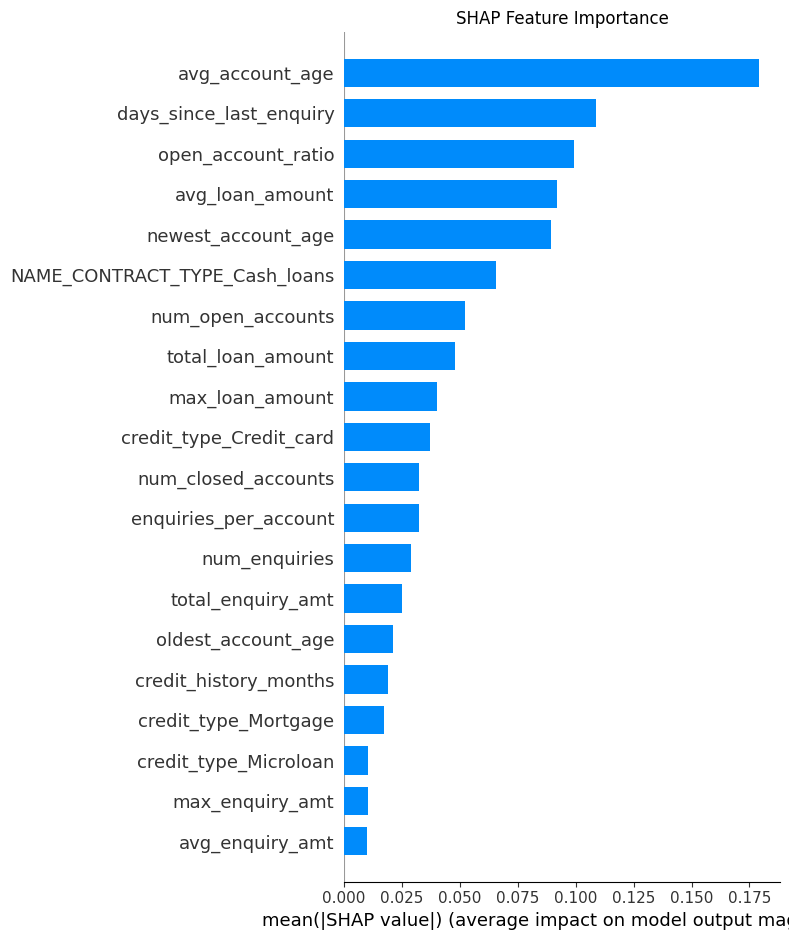

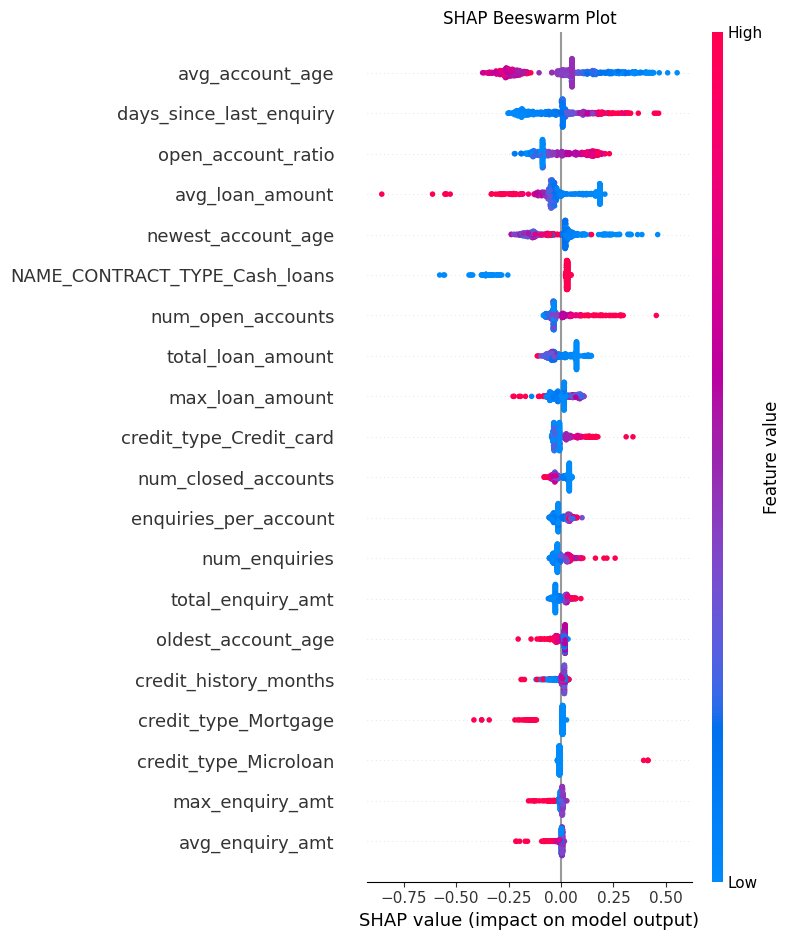

In [95]:
print("\nRunning SHAP Analysis...")

sample_idx = np.random.choice(
    len(X),
    size=min(500, len(X)),
    replace=False
)

X_sample = X.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb_models[0])

shap_values = explainer.shap_values(X_sample)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(
    sv,
    X_sample,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

shap.summary_plot(
    sv,
    X_sample,
    max_display=20,
    show=False
)

plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

Using SHAP, I found that credit-history age was the strongest predictor of default risk. Borrowers with newer accounts, higher enquiry activity, more open accounts, and larger loan exposure tended to have higher predicted risk. Interestingly, repayment-history features contributed less than expected, suggesting that account age and credit-seeking behavior carried more predictive signal in this dataset.

# Test Pipeline

I built test features using the same logic as training, filled missing values using training medians, one-hot encoded categorical variables, aligned the columns with the training dataset, and verified that the final test matrix matched the training feature structure before making predictions.

In [89]:
print("Building test features...")

features_test = build_features(
    accounts_long_test,
    enquiry_long_test,
    ACCT_REFERENCE_DATE,
    ENQ_REFERENCE_DATE
)

test = test_flag.merge(features_test, on='uid', how='left')


for col, med in train_medians.items():
    if col in test.columns:
        test[col] = test[col].fillna(med)

test = test.fillna(0)

X_test = test.drop(columns=['uid'], errors='ignore').copy()

cat_test = X_test.select_dtypes(include='object').columns.tolist()
X_test = pd.get_dummies(X_test, columns=cat_test)

X_test.columns = [
    c.replace(' ','_').replace('(','').replace(')','').replace('-','_')
    for c in X_test.columns
]


X_test = X_test.reindex(columns=TRAIN_COLUMNS, fill_value=0)

print(f"Test shape  : {X_test.shape}")
print(f"Train shape : {X.shape}")
assert X_test.shape[1] == X.shape[1], "Column mismatch between train and test!"


for col in ['enquiry_to_loan_ratio','overdue_per_account','enquiries_per_account','dpd_per_account']:
    nonzero = (X_test[col] != 0).sum()
    print(f"  {col}: {nonzero:,} non-zero test rows (should be >> 0)")

Building test features...
Test shape  : (46127, 56)
Train shape : (261383, 56)
  enquiry_to_loan_ratio: 39,572 non-zero test rows (should be >> 0)
  overdue_per_account: 505 non-zero test rows (should be >> 0)
  enquiries_per_account: 39,572 non-zero test rows (should be >> 0)
  dpd_per_account: 13,907 non-zero test rows (should be >> 0)


I generated predictions from each fold model and averaged them to reduce variance and improve stability. I then combined the Logistic Regression, LightGBM, and XGBoost predictions using both equal-weight and performance-weighted ensembles to produce the final default probabilities.

# Final Predictions


In [82]:
xgb_test_preds = np.mean(
    [
        model.predict_proba(X_test)[:, 1]
        for model in xgb_models
    ],
    axis=0
)

print(
    f"Prediction Range : "
    f"{xgb_test_preds.min():.4f} - "
    f"{xgb_test_preds.max():.4f}"
)

Prediction Range : 0.0680 - 0.8511


I created the final submission file by pairing each borrower ID with its predicted default probability and exported it in the required format for evaluation.

In [96]:
submission = pd.DataFrame({
    "uid": test["uid"],
    "pred": xgb_test_preds
})

submission.to_csv(
    "final_submission_Lakshya_Vipassana.csv",
    index=False
)

print("\nsubmission.csv saved ✅")
print(submission.head())



submission.csv saved ✅
           uid      pred
0  CMO22835242  0.195323
1  MRJ34316727  0.536025
2  UAV00534378  0.377557
3  IPQ08190402  0.248983
4  NQN84331006  0.364470
